<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>למידה סטטיסטית 99218</b><br>
<b>מטלת בית 1</b><br><br>

שם: נדב פיירמן שטרן<br>

</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import os
from google.colab import drive

drive.mount('/content/drive')

%matplotlib inline
plt.style.use('ggplot')
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Setup Complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup Complete


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>שאלה 1</b><br>
חוקר רוצה לבדוק האם סוג חנות הבגדים (סה"כ 4 סוגים) משפיע על המחיר הצפוי של הבגדים.<br>
שמונה פריטי לבוש נדגמו באופן אקראי מכל חנות כדי לבחון את ההשערה.<br>
את התוצאות ניתן למצוא בגיליון האלקטרוני של הבגדים בקובץ class.exe.01.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>א. הצגת שני מודלים תיאורטיים</b><br><br>


<b>i. מודל ANOVA (ניתוח שונות חד-גורמי)</b><br>
המודל מתאר את מחיר הפריט ה-j בחנות מסוג i:<br><br>

Y<sub>ij</sub> = μ + α<sub>i</sub> + ε<sub>ij</sub> &nbsp;&nbsp;&nbsp; i = 1,...,4 &nbsp;&nbsp;&nbsp; j = 1,...,8<br><br>

מרכיבי המודל:<br>
- μ – הממוצע הכללי של המחירים באוכלוסייה<br>
- α<sub>i</sub> – האפקט של סוג החנות i (הסטייה של ממוצע הקבוצה מהממוצע הכללי)<br>
- ε<sub>ij</sub> – טעות אקראית (רעש)<br><br>

הנחות המודל:<br>
- נורמליות – ε<sub>ij</sub> ~ N(0, σ²) לכל i, j<br>
- שוויון שונויות – Var(ε<sub>ij</sub>) = σ² קבוע לכל הקבוצות<br>
- אי-תלות – Cov = 0 לכל זוג תצפיות שונה<br><br>

אילוץ זיהוי:<br>
Σα<sub>i</sub> = 0 (i=1 עד 4)<br>
ללא אילוץ זה המודל אינו מזוהה – קיימים אינסוף צירופים של μ ו-α<sub>i</sub> המניבים את אותם ערכים חזויים. האילוץ עוגן את μ כממוצע הכללי האמיתי של האוכלוסייה.<br><br>

<b>ii. מודל רגרסיה</b><br>
ניתן לייצג את אותה בעיה באמצעות מודל רגרסיה המשתמש במשתני דמי לייצוג הקטגוריות השונות:<br><br>

Y<sub>j</sub> = β<sub>0</sub> + β<sub>1</sub>X<sub>1j</sub> + β<sub>2</sub>X<sub>2j</sub> + β<sub>3</sub>X<sub>3j</sub> + ε<sub>j</sub> &nbsp;&nbsp;&nbsp; j = 1,...,32<br><br>

מרכיבי המודל:<br>
- Y<sub>j</sub> – מחיר הפריט בתצפית j<br>
- β<sub>0</sub> – החותך, מייצג את ממוצע המחירים של חנות 4 (קבוצת הייחוס)<br>
- X<sub>kj</sub> – משתנה דמי המקבל את הערך 1 אם תצפית j שייכת לחנות k, ו-0 אחרת (עבור k = 1,2,3)<br>
- β<sub>k</sub> – מקדם הרגרסיה המייצג את הפרש המחיר הממוצע בין חנות k לחנות 4 (עבור k = 1,2,3)<br>
- ε<sub>j</sub> – מרכיב הטעות האקראית (שגיאה)<br><br>

הנחות המודל:<br>
- נורמליות – ε<sub>j</sub> ~ N(0, σ²) לכל j<br>
- שוויון שונויות – Var(ε<sub>j</sub>) = σ² קבוע לכל הקבוצות<br>
- עצמאות – Cov(ε<sub>j</sub>, ε<sub>j'</sub>) = 0 לכל j ≠ j'<br><br>

זיהוי המודל:<br>
משתמשים ב-k-1 = 3 משתני דמי עבור 4 קבוצות. השמטת הקבוצה הרביעית מונעת תלות ליניארית מלאה ומאפשרת ל-β<sub>0</sub> לייצג את ממוצע קבוצת הייחוס.

</div>

In [ ]:
path = '/content/drive/MyDrive/Statistical Learning/HW1/class.exe.01.xlsx'

all_sheets = pd.read_excel(path, sheet_name=None)

df_clothes = all_sheets['clothes']
df_one_var = all_sheets['one_var']
df_med = all_sheets['med']
df_grades = all_sheets['grades']
df_invest = all_sheets['invest']

In [ ]:
df_clothes.head()

,type,price
0,1,95
1,1,90
2,1,89
3,1,92
4,1,105


In [ ]:
df_one_var.head()

,region,salary
0,1,7.7100
1,1,6.4600
2,1,8.4200
3,1,6.5400
4,1,5.1300


In [ ]:
df_med.head()

,y,x1,x2
0,153.9608,94.3952,47.2396
1,169.7019,97.6982,48.4496
2,195.0770,115.5871,67.6137
3,198.0243,100.7051,59.0308
4,159.0579,101.2929,35.1530


In [ ]:
df_grades.head()

,real,guess,mood
0,58,64,1
1,70,68,1
2,84,86,1
3,68,71,1
4,63,71,1


In [ ]:
df_invest.head()

,channel,return
0,A,114.2260
1,A,139.0417
2,A,135.1075
3,A,58.8091
4,A,136.0695


In [ ]:
path = '/content/drive/MyDrive/Statistical Learning/HW1/rats.csv'
df_rats = pd.read_csv(path)

In [ ]:
df_rats.head()

,time,poison,treat
0,0.3100,I,A
1,0.8200,I,B
2,0.4300,I,C
3,0.4500,I,D
4,0.4500,I,A


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>ב. השערות, מבחנים והשוואה</b><br><br>

<b>i. מודל ANOVA</b><br>
השערות המבחן:<br>
H₀: α₁ = α₂ = α₃ = α₄ = 0<br>
H₁: αᵢ ≠ 0 – לפחות אחד מהם שונה מ-0<br>
$$F = \frac{MSB}{MSW} \sim_{H_0} F(K-1, N-K) = F(3,28)$$
<br>

<b>ii. מודל רגרסיה</b><br>
השערות המבחן:<br>
H₀: β₁ = β₂ = β₃ = 0<br>
H₁: βₖ ≠ 0 – לפחות אחד מהם שונה מ-0<br>
$$F = \frac{MS_{reg}}{MS_{res}} \sim_{H_0} F(K-1, N-K) = F(3,28)$$
<br>

<b>iii. בדיקה סטטיסטית</b><br>

</div>

In [ ]:
model_anova = smf.ols('price ~ C(type)', data=df_clothes).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print(anova_table)

model_reg = smf.ols('price ~ C(type, Treatment(reference=4))', data=df_clothes).fit()
F_stat = model_reg.fvalue
p_val = model_reg.f_pvalue
alpha = 0.05

print(f"\nF(3, 28) = {F_stat:.4f}")
print(f"p-value = {p_val:.2e}")
print(f"Reject H0: {p_val < alpha}")

             sum_sq      df        F  PR(>F)
C(type)  13508.8437  3.0000 217.2432  0.0000
Residual   580.3750 28.0000      NaN     NaN

F(3, 28) = 217.2432
p-value = 1.72e-19
Reject H0: True


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

מכיוון ש-p-value < α = 0.05 דוחים H₀ – קיים הבדל מובהק סטטיסטית בין ממוצעי המחירים של לפחות זוג אחד של חנויות.<br><br>

<b>iv. דמיון והבדל</b><br>
דמיון: אותו F ואותו p-value – המודלים שקולים.<br>
שוני: ANOVA בודק שוויון כל הממוצעים, רגרסיה בודקת מול קבוצת ייחוס.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ג. חישוב ממוצעי המחירים לפי מקדמי הרגרסיה</b><br><br>

ממודל הרגרסיה עם חנות 4 כקבוצת ייחוס, ממוצע כל חנות מחושב כך:<br><br>

μ̂₄ = β₀<br>
μ̂₁ = β₀ + β₁<br>
μ̂₂ = β₀ + β₂<br>
μ̂₃ = β₀ + β₃<br><br>

כלומר, β₀ הוא ממוצע חנות הייחוס (חנות 4), וכל β<sub>k</sub> מייצג את ההפרש בין חנות k לחנות 4.

</div>

In [ ]:
model_reg = ols('price ~ C(type, Treatment(reference=4))', data=df_clothes).fit()
params = model_reg.params

beta_0 = params['Intercept']
beta_1 = params['C(type, Treatment(reference=4))[T.1]']
beta_2 = params['C(type, Treatment(reference=4))[T.2]']
beta_3 = params['C(type, Treatment(reference=4))[T.3]']

means = {'Store 1': beta_0 + beta_1,
         'Store 2': beta_0 + beta_2,
         'Store 3': beta_0 + beta_3,
         'Store 4': beta_0}

for store, mean in means.items():
    print(f"{store}: {mean:.4f}")

Store 1: 96.0000
Store 2: 114.0000
Store 3: 123.8750
Store 4: 152.7500


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ד. חישוב אפקטי הקבוצות</b><br><br>

האפקט של כל קבוצה מוגדר כהסטייה של ממוצע הקבוצה מהממוצע הכללי:<br><br>

α̂ᵢ = Ȳᵢ - Ȳ<br><br>

כאשר Ȳ הוא הממוצע הכללי של כלל התצפיות, ו-Ȳᵢ הוא ממוצע החנות i שחושב בסעיף ג'.<br><br>

שים לב כי בהתאם לאילוץ הזיהוי: Σα̂ᵢ = 0

</div>

In [ ]:
grand_mean = df_clothes['price'].mean()

effects = {store: mean - grand_mean for store, mean in means.items()}

print(f"Grand Mean: {grand_mean:.4f}\n")
for store, effect in effects.items():
    print(f"{store}: effect = {effect:.4f}")

print(f"\nSum of effects: {sum(effects.values()):.6f}")

Grand Mean: 121.6562

Store 1: effect = -25.6562
Store 2: effect = -7.6562
Store 3: effect = 2.2188
Store 4: effect = 31.0938

Sum of effects: 0.000000


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>שאלה 2</b><br><br>

נתון המודל:<br><br>

</div>

$$Y_i = \beta I\{X_i > c\} + \epsilon_i, \qquad i = 1,\ldots,n$$

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

כאשר c > 0 והשגיאות מקיימות:<br>
a. נורמליות – $\epsilon_i \sim N(0, \sigma^2)$ לכל i<br>
b. שווי שונות – $\text{Var}(\epsilon_i) = \sigma^2$ קבוע<br>
c. עצמאות – $\text{Cov}(\epsilon_i, \epsilon_j) = 0$ לכל $i \neq j$<br><br>

שים לב כי המודל אינו כולל חותך — יש פרמטר יחיד לאמוד: $\beta$.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>א. גזירת אומדן OLS והשוואה ל-MLE</b><br><br>

כדי לאמוד את $\beta$ במודל $Y_i = \beta I_i + \epsilon_i$, נבצע גזירה בשלוש שיטות:<br><br>

<b>i. גזירה בצורה ישירה (Direct Form)</b><br>
בשיטת הריבועים הפחותים (OLS), אנו מחפשים את הערך של $\beta$ שמביא למינימום את סכום ריבועי השאריות (RSS):
$$S(\beta) = \sum_{i=1}^{n} (Y_i - \beta I_i)^2$$

נגזור לפי $\beta$ ונשווה לאפס:
$$\frac{dS}{d\beta} = -2 \sum_{i=1}^{n} I_i(Y_i - \beta I_i) = 0$$

נפתח את הסוגריים ונבודד את $\beta$:
$$\sum_{i=1}^{n} I_i Y_i - \beta \sum_{i=1}^{n} I_i^2 = 0 \implies \beta \cdot n_c = \sum_{i: X_i > c} Y_i$$

מאחר ו-$I_i$ הוא משתנה אינדיקטור, $\sum I_i^2$ הוא פשוט מספר התצפיות שעברו את הסף ($n_c$). לכן:
<div style="text-align: center;">
$$\hat{\beta}_{OLS} = \frac{\sum_{i: X_i > c} Y_i}{n_c} = \bar{Y}_{X>c}$$
</div>
<br>

<b>ii. גזירה בצורה מטריציונית (Matrix Form)</b><br>
נכתוב את המודל כ-$y = \mathbf{X}\beta + \epsilon$. מטריצת העיצוב $\mathbf{X}$ היא וקטור עמודה יחיד המכיל את ערכי האינדיקטורים. נוסחת ה-OLS היא:
$$\hat{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

נחשב את רכיבי הנוסחה:<br>
a. $\mathbf{X}^T \mathbf{X} = \sum_{i=1}^n I_i^2 = n_c$ (זהו מספר בודד, לכן ההופכי הוא $1/n_c$).<br>
b. $\mathbf{X}^T \mathbf{y} = \sum_{i=1}^n I_i Y_i = \sum_{i: X_i > c} Y_i$.<br>

<div style="text-align: center;">
$$\hat{\beta}_{OLS} = \frac{1}{n_c} \sum_{i: X_i > c} Y_i$$
</div>
<br>

<b>iii. השוואה לאומדן MLE</b><br>
תחת הנחת הנורמליות ($\epsilon_i \sim N(0, \sigma^2)$), פונקציית הנראות היא:
$$L(\beta) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \cdot e^{-\frac{(Y_i - \beta I_i)^2}{2\sigma^2}}$$

נוח יותר למקסם את הלוגריתם של פונקציית הנראות:
$$\ell(\beta) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n(Y_i - \beta I_i)^2$$

מקסום $\ell(\beta)$ שקול למזעור $\sum(Y_i - \beta I_i)^2$ — שהוא בדיוק ה-RSS של OLS.<br>
לכן <b>אומדן ה-MLE זהה לחלוטין לאומדן ה-OLS:</b><br>

<div style="text-align: center;">
$$\hat{\beta}_{MLE} = \hat{\beta}_{OLS} = \bar{Y}_{X>c}$$
</div>

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ב. תוחלת ושונות של האומדן</b><br><br>

<b>i. גזירה בצורה ישירה (Direct Form)</b><br><br>

<b>תוחלת האומדן:</b>
$$E[\hat{\beta}] = E\left[\frac{\sum_{i=1}^n I_i Y_i}{n_c}\right] = \frac{1}{n_c}\sum_{i=1}^n I_i E[Y_i]$$

נציב $E[Y_i] = \beta I_i$ (מאחר ו-$E[\epsilon_i] = 0$):
$$E[\hat{\beta}] = \frac{\beta}{n_c}\sum_{i=1}^n I_i^2 = \frac{\beta \cdot n_c}{n_c} = \beta$$

האומדן <b>חסר הטיה (Unbiased)</b>.<br><br>

<b>שונות האומדן:</b>
$$\text{Var}(\hat{\beta}) = \text{Var}\left(\frac{\sum_{i=1}^n I_i Y_i}{n_c}\right) = \frac{1}{n_c^2}\sum_{i=1}^n I_i^2 \text{Var}(Y_i)$$

נציב $\text{Var}(Y_i) = \sigma^2$ ו-$\sum I_i^2 = n_c$:
$$\text{Var}(\hat{\beta}) = \frac{\sigma^2 \cdot n_c}{n_c^2} = \frac{\sigma^2}{n_c}$$
<br>

<b>ii. גזירה בצורה מטריצית (Matrix Form)</b><br><br>

<b>תוחלת האומדן:</b>
$$E[\hat{\beta}] = E[(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}] = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T E[\mathbf{y}] = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{X}\beta = \beta$$

<b>שונות האומדן:</b>
$$\text{Var}(\hat{\beta}) = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \text{Var}(\mathbf{y})\, \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}$$

מאחר ש-$\text{Var}(\mathbf{y}) = \sigma^2\mathbf{I}$:
$$\text{Var}(\hat{\beta}) = \sigma^2(\mathbf{X}^T\mathbf{X})^{-1} = \frac{\sigma^2}{n_c}$$
<br>

<div style="text-align: center;">
$$E[\hat{\beta}] = \beta \qquad \text{Var}(\hat{\beta}) = \frac{\sigma^2}{n_c}$$
</div>

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>
<b>ג. חישוב האומדן הנקודתי והשונות המשוערת</b><br><br>

נתונים:<br>
$$c = 2, \quad x = (1, 0, -1, 3, 4, 5), \quad y = (10, 11, 12, 9, 10, 9)$$
<br>

<b>i. בניית וקטור האינדיקטורים</b><br>
לכל תצפית $i$, נבדוק האם $x_i > c = 2$:<br><br>

<table border="1" style="border-collapse: collapse; margin: auto; text-align: center; width: 60%;">
<tr style="background: #f2f2f2;"><th>$i$</th><th>$x_i$</th><th>$x_i > 2$?</th><th>$I_i$</th></tr>
<tr><td>1</td><td>1</td><td>לא</td><td>0</td></tr>
<tr><td>2</td><td>0</td><td>לא</td><td>0</td></tr>
<tr><td>3</td><td>-1</td><td>לא</td><td>0</td></tr>
<tr><td>4</td><td>3</td><td>כן</td><td>1</td></tr>
<tr><td>5</td><td>4</td><td>כן</td><td>1</td></tr>
<tr><td>6</td><td>5</td><td>כן</td><td>1</td></tr>
</table>
<br>
$$n_c = \sum_{i=1}^{6} I_i = 3$$
<br>

<b>ii. חישוב האומדן הנקודתי</b><br>
הצבה בנוסחה שגזרנו בסעיף א':
$$\hat\beta = \frac{1}{n_c}\sum_{i: x_i > c} y_i = \frac{y_4 + y_5 + y_6}{3} = \frac{9 + 10 + 9}{3} = \frac{28}{3} \approx 9.333$$
<br>

<b>iii. אמידת $\sigma^2$ מהשאריות</b><br>
מאחר ש-$\sigma^2$ <b>אינו נתון</b> בשאלה, נאמוד אותו מהשאריות:
$$\hat\sigma^2 = \frac{\sum_{i=1}^{n} e_i^2}{n - p}$$

כאשר $p = 1$ (מספר הפרמטרים), $n - p = 5$ (דרגות החופש של השאריות), ו-$\hat{y}_i = \hat\beta \cdot I_i$.<br><br>

<table border="1" style="border-collapse: collapse; margin: auto; text-align: center; width: 80%;">
<tr style="background: #f2f2f2;"><th>$i$</th><th>$y_i$</th><th>$I_i$</th><th>$\hat{y}_i$</th><th>$e_i$</th><th>$e_i^2$</th></tr>
<tr><td>1</td><td>10</td><td>0</td><td>0</td><td>10</td><td>100</td></tr>
<tr><td>2</td><td>11</td><td>0</td><td>0</td><td>11</td><td>121</td></tr>
<tr><td>3</td><td>12</td><td>0</td><td>0</td><td>12</td><td>144</td></tr>
<tr><td>4</td><td>9</td><td>1</td><td>9.333</td><td>-0.333</td><td>0.111</td></tr>
<tr><td>5</td><td>10</td><td>1</td><td>9.333</td><td>0.667</td><td>0.444</td></tr>
<tr><td>6</td><td>9</td><td>1</td><td>9.333</td><td>-0.333</td><td>0.111</td></tr>
</table>
<br>
$$\sum e_i^2 = 365.67 \implies \hat\sigma^2 = \frac{365.67}{5} \approx 73.13$$
<br>

<b>iv. חישוב השונות המשוערת</b><br>
הצבה בנוסחה שגזרנו בסעיף ב':
$$\widehat{\text{Var}}(\hat\beta) = \frac{\hat\sigma^2}{n_c} = \frac{73.13}{3} \approx 24.38$$

$$\widehat{SD}(\hat\beta) = \sqrt{24.38} \approx 4.94$$
<br>

</div>

In [ ]:
x = np.array([1, 0, -1, 3, 4, 5])
y = np.array([10, 11, 12, 9, 10, 9])
c = 2

I = (x > c).astype(float)
n_c = int(I.sum())

beta_hat = y[x > c].mean()

y_hat = beta_hat * I
residuals = y - y_hat
n, p = len(y), 1
sigma2_hat = np.sum(residuals**2) / (n - p)

var_beta = sigma2_hat / n_c
sd_beta  = np.sqrt(var_beta)

summary_q2c = pd.DataFrame({
    'Value': [n_c, beta_hat, sigma2_hat, var_beta, sd_beta]
}, index=['n_c', 'β̂', 'σ̂²', 'Var(β̂)', 'SD(β̂)'])
summary_q2c

,Value
n_c,3.0000
β̂,9.3333
σ̂²,73.1333
Var(β̂),24.3778
SD(β̂),4.9374


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>ד. בדיקת מובהקות המודל</b><br><br>

<b>i. השערות המבחן</b><br>
$$H_0: \beta = 0 \qquad \text{מול} \qquad H_1: \beta \neq 0$$
תחת $H_0$, המשתנה $I\{X_i > c\}$ אינו תורם מידע לחיזוי של $Y$, כלומר הסף $c$ אינו משפיע על התוחלת של $Y$.<br><br>

<b>ii. סטטיסטי המבחן</b><br>
מאחר ש-$\sigma^2$ אינו נתון ונאמד מהמדגם, סטטיסטי המבחן מתפלג לפי התפלגות t של סטיודנט:
$$t_s = \frac{\hat\beta - 0}{\widehat{SD}(\hat\beta)} \sim_{H_0} t_{(n-p)}$$
כאשר $n - p = 6 - 1 = 5$ הן דרגות החופש של השאריות.<br><br>

<b>iii. חישוב הסטטיסטי</b><br>
$$t_s = \frac{\hat\beta}{\widehat{SD}(\hat\beta)} = \frac{9.333}{4.94} \approx 1.890$$
<br>

<b>iv. ערך קריטי ו-p-value</b><br>
$$t_c = t_{0.975,\,5} \approx 2.571$$
$$\text{p-value} = 2 \cdot P(T > |t_s|) \approx 0.117$$
<br>

<b>v. מסקנה</b><br>
$$|t_s| = 1.890 < t_c = 2.571$$
$$\text{p-value} = 0.117 > \alpha = 0.05$$
מאחר שהסטטיסטי לא עבר את הערך הקריטי (וה-p-value גדול מ-$\alpha$), <b>לא דוחים את $H_0$</b>.<br><br>

<div style="text-align: center;">
<b>$$t_s \approx 1.890, \quad t_c \approx 2.571, \quad \text{p-value} \approx 0.117 \implies \text{לא דוחים } H_0$$</b>
</div>

</div>

In [ ]:
t_s     = beta_hat / sd_beta
df      = n - p
p_value = 2 * (1 - stats.t.cdf(abs(t_s), df))
alpha   = 0.05
t_c     = stats.t.ppf(1 - alpha/2, df)

test_q2d = pd.DataFrame({
    'Value': [t_s, df, t_c, p_value, p_value < alpha]
}, index=['t_s', 'df', 't_c (α=0.05)', 'p-value', 'Reject H₀?'])
test_q2d

,Value
t_s,1.8903
df,5
t_c (α=0.05),2.5706
p-value,0.1173
Reject H₀?,False


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>ה. רווח סמך 95%</b><br><br>

<b>i. הנוסחה</b><br>
מאחר ש-$\sigma^2$ אינו ידוע, רווח הסמך מבוסס על התפלגות $t$:
$$\hat\beta \pm t_{1-\alpha/2,\,n-p} \cdot \widehat{SD}(\hat\beta)$$
עבור $\alpha = 0.05$ ו-$df = n - p = 5$, הערך הקריטי הוא $t_c = t_{0.975,\,5} \approx 2.571$ (זהה ל-$t_c$ מסעיף ד').<br><br>

<b>ii. חישוב הגבולות</b><br>
$$L = \hat\beta - t_c \cdot \widehat{SD}(\hat\beta) = 9.333 - 2.571 \cdot 4.94 \approx -3.359$$
$$U = \hat\beta + t_c \cdot \widehat{SD}(\hat\beta) = 9.333 + 2.571 \cdot 4.94 \approx 22.025$$
<br>

<b>iii. תוצאה</b><br>
$$\beta \in [-3.359,\ 22.025]$$
רווח הסמך <b>כולל את האפס</b>, בעקביות עם המסקנה בסעיף ד' שבו לא דחינו את $H_0: \beta = 0$.<br><br>

</div>

In [ ]:
ci_low  = beta_hat - t_c * sd_beta
ci_high = beta_hat + t_c * sd_beta

ci_q2e = pd.DataFrame({
    'Lower (2.5%)':    [ci_low],
    'β̂ (point)':      [beta_hat],
    'Upper (97.5%)':   [ci_high]
})
ci_q2e

,Lower (2.5%),β̂ (point),Upper (97.5%)
0,-3.3586,9.3333,22.0253


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>ו. חזרה על החישובים ב-Python</b><br><br>

נריץ את המודל $Y_i = \beta I\{X_i > c\} + \epsilon_i$ באמצעות הפונקציה <code>smf.ols</code> של <code>statsmodels</code>, ונשווה את התוצאות לחישובים הידניים מסעיפים ג'-ה'.<br><br>

<b>i. הגדרת המודל והרצתו</b><br>
נגדיר את המודל באמצעות נוסחה: <code>y ~ ind - 1</code>, כאשר <code>ind</code> הוא וקטור האינדיקטורים. ה-<code>-1</code> בנוסחה אומר ל-statsmodels לא לכלול חותך, בהתאם למודל שלנו.

</div>

In [ ]:
df_q2 = pd.DataFrame({'y': y, 'ind': I})

model_q2 = smf.ols('y ~ ind - 1', data=df_q2).fit()
model_q2.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.417
Model:                            OLS   Adj. R-squared (uncentered):              0.300
Method:                 Least Squares   F-statistic:                              3.573
Date:                Sun, 19 Apr 2026   Prob (F-statistic):                       0.117
Time:                        08:17:18   Log-Likelihood:                         -20.844
No. Observations:                   6   AIC:                                      43.69
Df Residuals:                       5   BIC:                                      43.48
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
ind            9.3333      4.937      1.890      0.117      -3.359      22.025
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   0.427
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.945
Skew:                           0.022   Prob(JB):                        0.623
Kurtosis:                       1.056   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>ii. השוואה בין החישוב הידני ל-statsmodels</b><br>
נציג טבלה המשווה את הערכים שחישבנו ידנית בסעיפים ג'-ה' לערכים ש-<code>statsmodels</code> מפיק:

</div>

In [ ]:
comparison = pd.DataFrame({
    'Manual': [beta_hat, sd_beta, t_s, p_value, ci_low, ci_high],
    'statsmodels': [
        model_q2.params.iloc[0],
        model_q2.bse.iloc[0],
        model_q2.tvalues.iloc[0],
        model_q2.pvalues.iloc[0],
        model_q2.conf_int(0.05).iloc[0, 0],
        model_q2.conf_int(0.05).iloc[0, 1]
    ]
}, index=['β̂', 'SD(β̂)', 't_s', 'p-value', 'CI low', 'CI high'])
comparison

,Manual,statsmodels
β̂,9.3333,9.3333
SD(β̂),4.9374,4.9374
t_s,1.8903,1.8903
p-value,0.1173,0.1173
CI low,-3.3586,-3.3586
CI high,22.0253,22.0253


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>iii. דמיון והבדלים</b><br><br>

דמיון:<br>
- כל הערכים <b>זהים לחלוטין</b> בין החישוב הידני ל-<code>statsmodels</code>. זה לא במקרה — הכלי מיישם את אותן נוסחאות $(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ שגזרנו ידנית בסעיפים א'-ב'.<br>
- ה-<code>statsmodels</code> אומד את $\sigma^2$ בדיוק כמו שעשינו (מחלוקה ב-$n-p$), מחשב את סטיית התקן, את סטטיסטי $t$, את ה-p-value ואת רווח הסמך — כולם עם אותה מתודולוגיה.<br><br>

הבדלים:<br>
- <b>נוחות:</b> ב-<code>statsmodels</code> כל התהליך מתבצע בשורה אחת (<code>smf.ols('y ~ ind - 1', data=df).fit()</code>). בחישוב הידני נדרשו מספר שלבים: חישוב שאריות, אמידת $\sigma^2$, הצבה בנוסחת $t$, מציאת ערך קריטי, וכו'.<br>
- <b>שליטה:</b> בחישוב הידני אנחנו רואים כל שלב, מה שמאפשר הבנה עמוקה יותר ואבחון שגיאות.<br>
- <b>$R^2$ בפלט:</b> שים לב ש-<code>statsmodels</code> מציג <code>R-squared (uncentered)</code> במקום $R^2$ רגיל, כי המודל אינו כולל חותך. זו אינדיקציה חשובה שהמודל שלנו חריג — אין לפרש את הערך הזה כ"אחוז השונות המוסברת" במובן הקלאסי.<br><br>

מסקנה:<br>
החישוב הידני וה-<code>statsmodels</code> נותנים אותן תוצאות בדיוק. היתרון של הכלי האוטומטי הוא מהירות ונוחות, והיתרון של החישוב הידני הוא הבנה של מה קורה "מתחת למכסה".

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>שאלה 3</b><br>
מנהל תיקי השקעות רוצה לבדוק האם ישנם הבדלים בתשואה השנתית הצפויה בתיקי השקעות באסטרטגיות השקעה שונות (A, B, C, D).<br>
הנתונים נמצאים ב-class.exe.01, גיליון בשם invest.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>א. בדיקה ויזואלית של נורמליות</b><br><br>

נבדוק האם התשואות של כל אסטרטגיה מפולגות בקירוב נורמלי. נעשה זאת בשני אופנים:

<ul style="list-style-type: circle;">
<li>היסטוגרמה לכל קבוצה עם עקומת נורמלית מונחת — בדיקה ויזואלית.</li>
<li>מבחן Shapiro-Wilk לכל קבוצה — מבחן סטטיסטי פורמלי לנורמליות.</li>
</ul>

<b>i. סטטיסטיקות תיאוריות</b><br>
נציג סיכום כללי של התשואות בכל אסטרטגיה.

</div>

In [ ]:
desc_stats = df_invest.groupby('channel')['return'].agg(['count', 'mean', 'std', 'min', 'max'])
desc_stats

,count,mean,std,min,max
channel,,,,,
A,19,84.4249,40.9474,2.9895,139.0417
B,20,39.2327,23.9012,2.2268,74.5364
C,21,33.1254,17.7803,3.4658,58.4592
D,21,57.8373,35.3998,2.6376,109.7957


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>ii. היסטוגרמות עם עקומת נורמלית</b><br>
לכל אסטרטגיה נצייר היסטוגרמה של התשואות ומעליה עקומת נורמלית המתאימה לממוצע ולסטיית התקן של הקבוצה. אם ההתפלגות נורמלית, ההיסטוגרמה צריכה להצמד לעקומה.

</div>

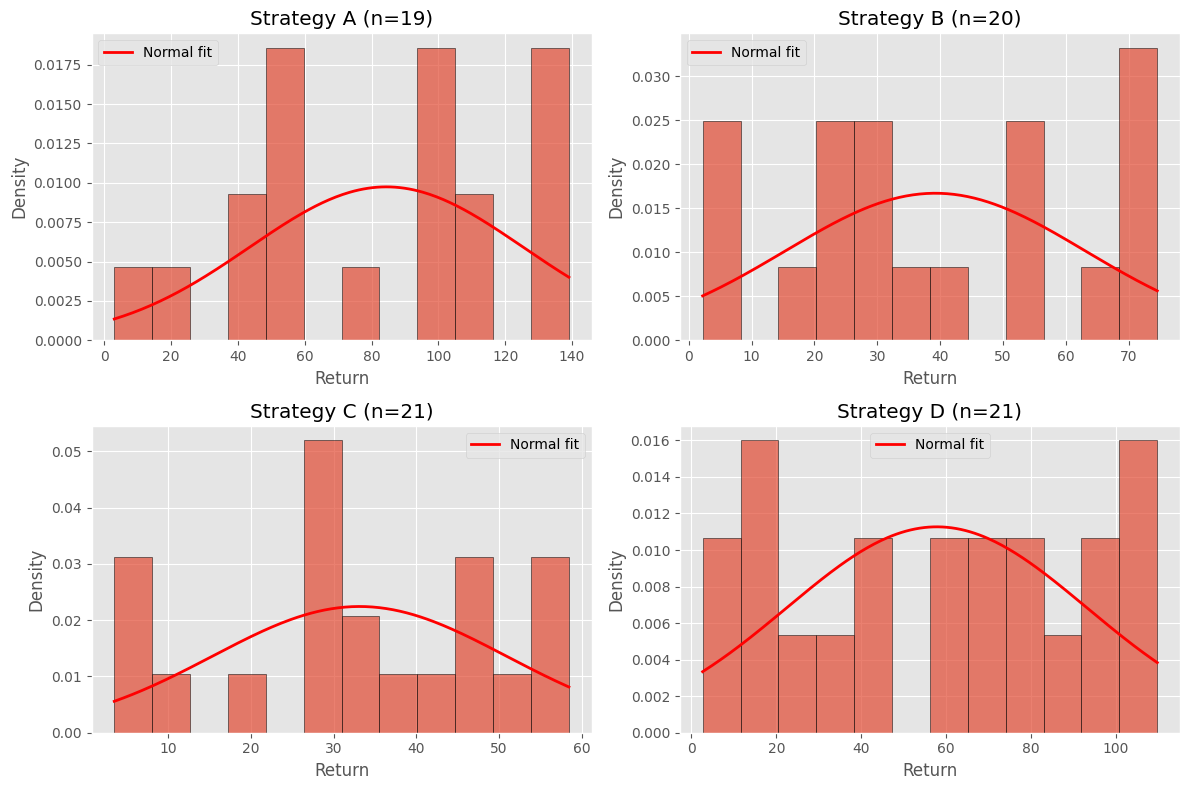

In [ ]:
channels = sorted(df_invest['channel'].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, ch in zip(axes, channels):
    data = df_invest.loc[df_invest['channel'] == ch, 'return']
    ax.hist(data, bins=12, density=True, alpha=0.7, edgecolor='black')
    xs = np.linspace(data.min(), data.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, data.mean(), data.std()), 'r-', lw=2, label='Normal fit')
    ax.set_title(f'Strategy {ch} (n={len(data)})')
    ax.set_xlabel('Return')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>iii. מבחן Shapiro-Wilk</b><br>
מבחן פורמלי לנורמליות, עם ההשערות:<br>
$$H_0: \text{הנתונים מפולגים נורמלית} \qquad H_1: \text{הנתונים אינם נורמליים}$$
דוחים את $H_0$ אם $p\text{-value} < 0.05$.

</div>

In [ ]:
shapiro_results = []
for ch in channels:
    data = df_invest.loc[df_invest['channel'] == ch, 'return']
    W, p = stats.shapiro(data)
    shapiro_results.append({'Strategy': ch, 'W': W, 'p-value': p, 'Normal?': p > 0.05})

shapiro_df = pd.DataFrame(shapiro_results).set_index('Strategy')
shapiro_df

,W,p-value,Normal?
Strategy,,,
A,0.9387,0.2497,True
B,0.9320,0.1689,True
C,0.9315,0.1475,True
D,0.9322,0.1523,True


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>iv. מסקנה</b><br><br>

הבדיקה הויזואלית מראה שההתפלגויות בכל ארבע האסטרטגיות <b>אינן נראות נורמליות</b>:<br>
- אסטרטגיה A: התפלגות דו-שיאית עם שיא סביב 50-60 ושיא נוסף סביב 100-140.<br>
- אסטרטגיה B: התפלגות שטוחה, קרובה להתפלגות אחידה יותר מאשר לפעמון.<br>
- אסטרטגיה C: קרובה יחסית לנורמלי עם שיא מרכזי אך זנבות לא סימטריים.<br>
- אסטרטגיה D: התפלגות דו-שיאית עם שיאים סביב 15 וסביב 100.<br><br>

מבחן Shapiro-Wilk לא דוחה נורמליות באף אחת מהקבוצות ($p > 0.05$ לכולן), אך יש לקחת תוצאה זו בזהירות:<br>
- גודל המדגם בכל קבוצה קטן יחסית ($n \approx 20$), ולכן כוח המבחן לדחות נורמליות נמוך.<br>
- ההיסטוגרמות מראות בבירור סטיות מנורמליות, גם אם המבחן הפורמלי לא דוחה.<br><br>

מסקנה: יש ספק ממשי לגבי מידת הנורמליות של ההתפלגויות. נמשיך עם ה-ANOVA הפרמטרי בסעיף ב', ובסעיף ד' נבחן האם כדאי גישה אי-פרמטרית.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ב. מבחן ANOVA</b><br><br>

<b>i. המודל התיאורטי</b><br>
נשתמש במודל ANOVA חד-כיווני:
$$Y_{ij} = \mu + \tau_j + \epsilon_{ij}, \quad j \in \{A, B, C, D\}, \quad i = 1, \ldots, n_j$$

מרכיבי המודל:
<ul style="list-style-type: circle;">
<li>$Y_{ij}$ — התשואה של תצפית $i$ באסטרטגיה $j$</li>
<li>$\mu$ — הממוצע הכללי של התשואות באוכלוסייה</li>
<li>$\tau_j$ — אפקט אסטרטגיה $j$ (סטייה מהממוצע הכללי)</li>
<li>$\epsilon_{ij}$ — טעות אקראית</li>
</ul>

הנחות המודל:
<ul style="list-style-type: circle;">
<li>נורמליות — $\epsilon_{ij} \sim N(0, \sigma^2)$</li>
<li>שוויון שונויות — $\text{Var}(\epsilon_{ij}) = \sigma^2$ קבוע בכל הקבוצות</li>
<li>אי-תלות — $\text{Cov}(\epsilon_{ij}, \epsilon_{kl}) = 0$ עבור תצפיות שונות</li>
</ul>

אילוץ זיהוי: $\sum_j n_j \tau_j = 0$<br><br>

<b>ii. השערות המבחן</b><br>
$$H_0: \mu_A = \mu_B = \mu_C = \mu_D$$
$$H_1: \text{לפחות זוג אחד של תוחלות שונה}$$

<b>iii. סטטיסטי המבחן</b><br>
$$F = \frac{MS_B}{MS_W} \sim_{H_0} F(k-1,\, N-k) = F(3, 77)$$
כאשר $k = 4$ הוא מספר הקבוצות ו-$N = 81$ הוא סך התצפיות.

</div>

In [ ]:
model_inv = smf.ols('Q("return") ~ C(channel)', data=df_invest).fit()
anova_inv = sm.stats.anova_lm(model_inv, typ=2)
anova_inv

,sum_sq,df,F,PR(>F)
C(channel),31339.6155,3.0000,11.1072,0.0000
Residual,72420.2209,77.0000,NaN,NaN


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>iv. סיכום המודל</b><br>
נציג את ה-summary המלא של המודל הכולל גם את המקדמים (נשתמש בהם בסעיף ג' לפוסט-הוק).

</div>

In [ ]:
model_inv.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Q("return")   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     11.11
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           3.88e-06
Time:                        08:17:21   Log-Likelihood:                -390.16
No. Observations:                  81   AIC:                             788.3
Df Residuals:                      77   BIC:                             797.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          84.4249      7.036     11.999      0.000      70.415      98.435
C(channel)[T.B]   -45.1922      9.825     -4.600      0.000     -64.756     -25.628
C(channel)[T.C]   -51.2994      9.710     -5.283      0.000     -70.635     -31.964
C(channel)[T.D]   -26.5875      9.710     -2.738      0.008     -45.923      -7.252
==============================================================================
Omnibus:                        1.570   Durbin-Watson:                   1.689
Prob(Omnibus):                  0.456   Jarque-Bera (JB):                1.371
Skew:                          -0.165   Prob(JB):                        0.504
Kurtosis:                       2.455   Cond. No.                         4.93
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>v. מסקנה</b><br>
$$F \approx 11.11, \quad p\text{-value} \approx 3.9 \times 10^{-6}$$

מאחר ש-$p\text{-value} \ll 0.05$, <b>דוחים את $H_0$</b> — קיים הבדל מובהק סטטיסטית בתוחלות התשואה בין לפחות שתי אסטרטגיות.<br><br>

$R^2 \approx 0.302$ — כלומר, האסטרטגיה מסבירה כ-30% מהשונות בתשואות. המסקנה הבאה היא לבדוק <b>בין אילו זוגות</b> קיים הבדל מובהק — זה מה שנעשה בסעיף ג'.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ג. פוסט-הוק עם Fisher LSD, Bonferroni, ו-FDR</b><br><br>

בסעיף ב' דחינו את $H_0$ הכללית — יש הבדל בין התוחלות. עתה נבדוק <b>בין אילו זוגות</b> של אסטרטגיות קיים הבדל מובהק. עם 4 קבוצות יש $\binom{4}{2} = 6$ השוואות זוגיות.<br><br>

אילו היינו בודקים כל השוואה ברמת מובהקות $\alpha = 0.05$ ללא תיקון, הסיכוי לדחות לפחות השערה אחת מטעות (FWER) היה:
$$1 - (1 - 0.05)^6 \approx 0.26$$
כלומר 26% — גבוה מדי. לכן נבצע שלושה סוגי תיקונים:

<ul style="list-style-type: circle;">
<li><b>Fisher's LSD:</b> t-test רגיל עם שונות מאוחדת מה-ANOVA, ללא תיקון. חזק אך לא שולט ב-FWER.</li>
<li><b>Bonferroni:</b> מחלקים את $\alpha$ במספר ההשוואות ($\alpha_c = \alpha/m$). שומר על FWER אך שמרני במיוחד.</li>
<li><b>FDR (Benjamini-Hochberg):</b> שולט בפרופורציה הצפויה של גילויים שגויים מכל הדחיות. ביניים בין LSD ל-Bonferroni.</li>
</ul>

</div>

In [ ]:
from itertools import combinations

channels = sorted(df_invest['channel'].unique())
pairs    = list(combinations(channels, 2))

raw_p = []
for a, b in pairs:
    d1 = df_invest.loc[df_invest['channel'] == a, 'return']
    d2 = df_invest.loc[df_invest['channel'] == b, 'return']
    t, p = stats.ttest_ind(d1, d2, equal_var=True)
    raw_p.append(p)

_, bonf_p, _, _ = multipletests(raw_p, method='bonferroni')
_, fdr_p,  _, _ = multipletests(raw_p, method='fdr_bh')

results = pd.DataFrame({
    'Pair':          [f'{a} vs {b}' for a, b in pairs],
    'LSD p-value':   raw_p,
    'Bonferroni':    bonf_p,
    'FDR (BH)':      fdr_p,
})
results['LSD reject']  = results['LSD p-value'] < 0.05
results['Bonf reject'] = results['Bonferroni']  < 0.05
results['FDR reject']  = results['FDR (BH)']    < 0.05
results.set_index('Pair')

,LSD p-value,Bonferroni,FDR (BH),LSD reject,Bonf reject,FDR reject
Pair,,,,,,
A vs B,0.0001,0.0009,0.0004,True,True,True
A vs C,0.0000,0.0000,0.0000,True,True,True
A vs D,0.0338,0.2027,0.0507,True,False,False
B vs C,0.3574,1.0000,0.3574,False,False,False
B vs D,0.0569,0.3414,0.0683,False,False,False
C vs D,0.0067,0.0403,0.0134,True,True,True


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>i. סיכום הממצאים</b><br><br>

ניתן לחלק את 6 הזוגות לשלוש קבוצות:

<ul style="list-style-type: circle;">
<li><b>מובהקים בכל שלוש השיטות:</b> A vs B, A vs C, C vs D — הבדלים חזקים שיתקיימו תחת כל תיקון.</li>
<li><b>מובהקים רק ב-LSD:</b> A vs D ($p_{LSD} \approx 0.034$) — נדחה רק בשיטה הליברלית, לא שורד את Bonferroni או FDR.</li>
<li><b>לא מובהקים בכל השיטות:</b> B vs C, B vs D — אין עדות להבדל.</li>
</ul>

<b>ii. השוואה בין השיטות</b><br><br>

<ul style="list-style-type: circle;">
<li><b>Fisher LSD</b> — הכי ליברלי. דוחה 4 זוגות (A-B, A-C, A-D, C-D). ללא הגנה על FWER.</li>
<li><b>Bonferroni</b> — הכי שמרני. דוחה רק 3 זוגות (A-B, A-C, C-D). ערכי ה-p מוכפלים ב-6.</li>
<li><b>FDR (BH)</b> — ביניים. גם דוחה 3 זוגות, אבל עם ערכי p נמוכים יותר מאלה של Bonferroni (כלומר יותר כוח להבחין).</li>
</ul>

<b>iii. מסקנה</b><br>
ההבדלים המובהקים העיקריים הם בין אסטרטגיה A (הגבוהה) לבין B ו-C (הנמוכות), ובין C ל-D. הזוג A-D "חי על הגבול" — מובהק בשיטה הליברלית אך לא בשמרנית. הבחירה בין השיטות תלויה בהקשר: אם חשוב מאוד לא לדחות בטעות, נשתמש ב-Bonferroni. אם הניסוי הוא חקרני עם הרבה השוואות, FDR מתאים יותר.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ד. התאמת המודל הנורמלי וגישה חלופית</b><br><br>

<b>i. האם המודל הנורמלי התאים?</b><br>
לדעתנו המודל הפרמטרי הנורמלי <b>אינו מתאים</b> לנתונים. שלוש סיבות מרכזיות:

<ul style="list-style-type: circle;">
<li><b>נורמליות מופרת:</b> מההיסטוגרמות בסעיף א' ראינו שההתפלגויות אינן פעמון — A ו-D דו-שיאיות, B קרובה לאחידה, רק C מזכירה נורמלי. מבחן Shapiro-Wilk לא דחה נורמליות, אך עם מדגם של $n \approx 20$ לכוח המבחן אין יכולת ממשית לדחות גם כשההפרה קיימת.</li>
<li><b>שוויון שונויות מופר:</b> סטיות התקן שונות מהותית בין הקבוצות ($\text{std}_A \approx 41$ לעומת $\text{std}_C \approx 18$). היחס הוא מעל 2, שזו אינדיקציה ברורה להפרת ההנחה.</li>
<li><b>אופי הנתונים:</b> תשואות פיננסיות נוטות להיות לא נורמליות מעצם טבען — זנבות כבדים, אסימטריה, ותצפיות חריגות הן מאפיין מובנה.</li>
</ul>

<b>ii. גישה חלופית — אי-פרמטרית</b><br>
נעבור למבחנים המבוססים על <b>דרגות</b> של התצפיות במקום הערכים עצמם. שיטה זו עמידה מול הפרות של נורמליות ושוויון שונויות.

<ul style="list-style-type: circle;">
<li><b>Kruskal-Wallis</b> — חלופה ל-ANOVA חד-כיווני. בודק האם ההתפלגויות של כל הקבוצות זהות, מבוסס על סכומי דרגות.</li>
<li><b>Mann-Whitney U</b> — חלופה ל-t-test זוגי, לפוסט-הוק. עם תיקוני Bonferroni ו-FDR לערכי p.</li>
</ul>

הנחה יחידה: אי-תלות של התצפיות. אין צורך בנורמליות או בשוויון שונויות.

<b>iii. מבחן Kruskal-Wallis</b><br>
השערות המבחן:
$$H_0: F_A = F_B = F_C = F_D \qquad H_1: \text{לפחות אחת מההתפלגויות שונה}$$
סטטיסטי המבחן מתפלג בקירוב $\chi^2_{(k-1)} = \chi^2_{(3)}$ תחת $H_0$.

</div>

In [ ]:
groups = [df_invest.loc[df_invest['channel']==ch, 'return'].values for ch in channels]
H_stat, p_kw = stats.kruskal(*groups)

pd.DataFrame({
    'Value': [H_stat, p_kw, p_kw < 0.05]
}, index=['Kruskal-Wallis H', 'p-value', 'Reject H₀?'])

,Value
Kruskal-Wallis H,19.5815
p-value,0.0002
Reject H₀?,True


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>iv. פוסט-הוק: Mann-Whitney + תיקונים</b><br>
נריץ Mann-Whitney לכל אחד מ-6 הזוגות, ונחיל את תיקוני Bonferroni ו-FDR לערכי p.

</div>

In [ ]:
raw_p_mw = []
for a, b in pairs:
    d1 = df_invest.loc[df_invest['channel']==a, 'return']
    d2 = df_invest.loc[df_invest['channel']==b, 'return']
    U, p = stats.mannwhitneyu(d1, d2, alternative='two-sided')
    raw_p_mw.append(p)

_, bonf_mw, _, _ = multipletests(raw_p_mw, method='bonferroni')
_, fdr_mw,  _, _ = multipletests(raw_p_mw, method='fdr_bh')

results_mw = pd.DataFrame({
    'Pair':         [f'{a} vs {b}' for a, b in pairs],
    'MW p-value':   raw_p_mw,
    'Bonferroni':   bonf_mw,
    'FDR':          fdr_mw,
})
results_mw['MW rej']   = results_mw['MW p-value'] < 0.05
results_mw['Bonf rej'] = results_mw['Bonferroni'] < 0.05
results_mw['FDR rej']  = results_mw['FDR']        < 0.05
results_mw.set_index('Pair')

,MW p-value,Bonferroni,FDR,MW rej,Bonf rej,FDR rej
Pair,,,,,,
A vs B,0.0009,0.0052,0.0026,True,True,True
A vs C,0.0001,0.0005,0.0005,True,True,True
A vs D,0.0396,0.2373,0.0593,True,False,False
B vs C,0.3966,1.0000,0.3966,False,False,False
B vs D,0.1087,0.6522,0.1304,False,False,False
C vs D,0.0286,0.1718,0.0573,True,False,False


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>v. השוואה למסקנות הפרמטריות ומסקנה סופית</b><br><br>

תוצאות Kruskal-Wallis ($H \approx 19.58, p \approx 2 \times 10^{-4}$) <b>מאשרות את מסקנת ה-ANOVA</b> — קיים הבדל מובהק בין התפלגויות התשואה של האסטרטגיות.<br><br>

גם הפוסט-הוק האי-פרמטרי מוביל ל<b>אותם ממצאים</b> כמו הפרמטרי:

<ul style="list-style-type: circle;">
<li>הזוגות A-B ו-A-C מובהקים בכל השיטות.</li>
<li>הזוג A-D על הגבול (כמו בניתוח הפרמטרי).</li>
<li>B-C ו-B-D לא מובהקים.</li>
</ul>

<b>מסקנה סופית:</b> למרות שהמודל הנורמלי הפרמטרי לא אידיאלי לנתונים הללו, שני הניתוחים (פרמטרי ואי-פרמטרי) מובילים לאותן מסקנות מהותיות. זה <b>מחזק את אמינות הממצאים</b> — הם יציבים ולא תלויים בבחירת השיטה הסטטיסטית. בדיווח מדעי רצוי להציג את שני הניתוחים; אם יש פער ביניהם, יש להעדיף את הניתוח האי-פרמטרי שאינו תלוי בהנחות שהופרו.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>שאלה 4</b><br><br>

השתמשו בקובץ <b>rats.csv</b>. קובץ זה מכיל נתונים מניסוי טוקסיקולוגי על עכברים.  
48 העכברים חולקו באופן אקראי לקבל שלושה סוגי רעלים (I, II ו-III) וארבע קבוצות טיפול (A, B, C, D).  
המשתנה התלוי הוא זמן התגובה לגירוי נתון.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>א. איזון הניסוי ו-Box-Plots</b><br><br>

<b>i. בדיקת איזון</b><br>
ניסוי מאוזן הוא ניסוי שבו יש מספר שווה של תצפיות בכל שילוב של רמות (תא). בנתונים שלנו יש $3 \times 4 = 12$ תאים ו-48 עכברים, כך שאם הניסוי מאוזן יהיו $48/12 = 4$ תצפיות בכל תא.<br>
נציג את ספירות התצפיות בטבלת צלבים:

</div>

In [ ]:
cell_counts = pd.crosstab(df_rats['poison'], df_rats['treat'])
cell_counts

treat,A,B,C,D
poison,,,,
I,4,4,4,4
II,4,4,4,4
III,4,4,4,4


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

כפי שניתן לראות, <b>יש בדיוק 4 תצפיות בכל אחד מ-12 התאים</b>. הניסוי מאוזן לחלוטין.<br><br>

<b>ii. תרשימי תיבות (Box-Plots)</b><br>
נצייר שלושה גרפים:
<ul style="list-style-type: circle;">
<li>זמן תגובה לפי רעל (מתעלם מהטיפול) — השפעת הרעל.</li>
<li>זמן תגובה לפי טיפול (מתעלם מהרעל) — השפעת הטיפול.</li>
<li>זמן תגובה לפי שילוב של שניהם — מאפשר לזהות אינטראקציה.</li>
</ul>

</div>

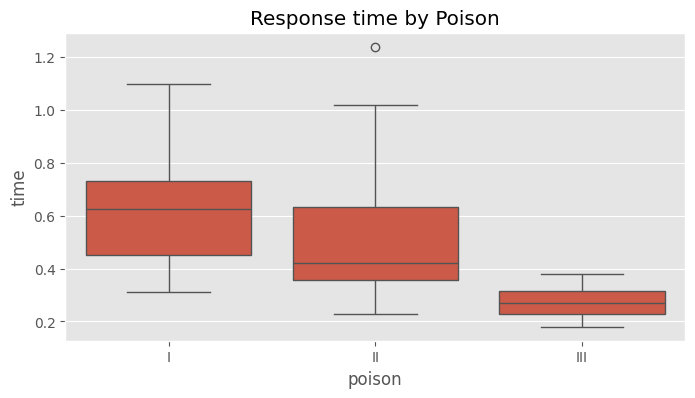

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_rats, x='poison', y='time', order=['I', 'II', 'III'])
plt.title('Response time by Poison')
plt.show()

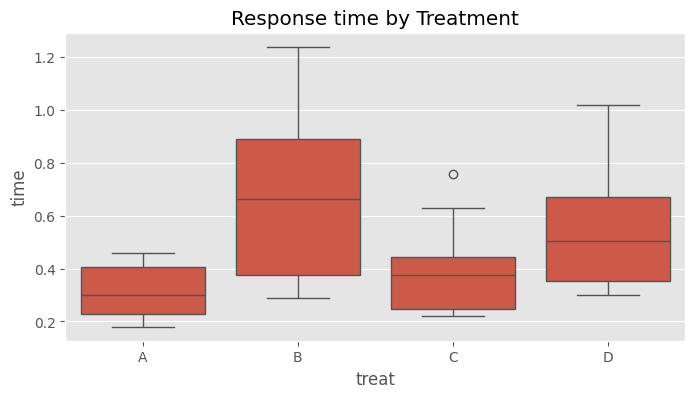

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_rats, x='treat', y='time', order=['A', 'B', 'C', 'D'])
plt.title('Response time by Treatment')
plt.show()

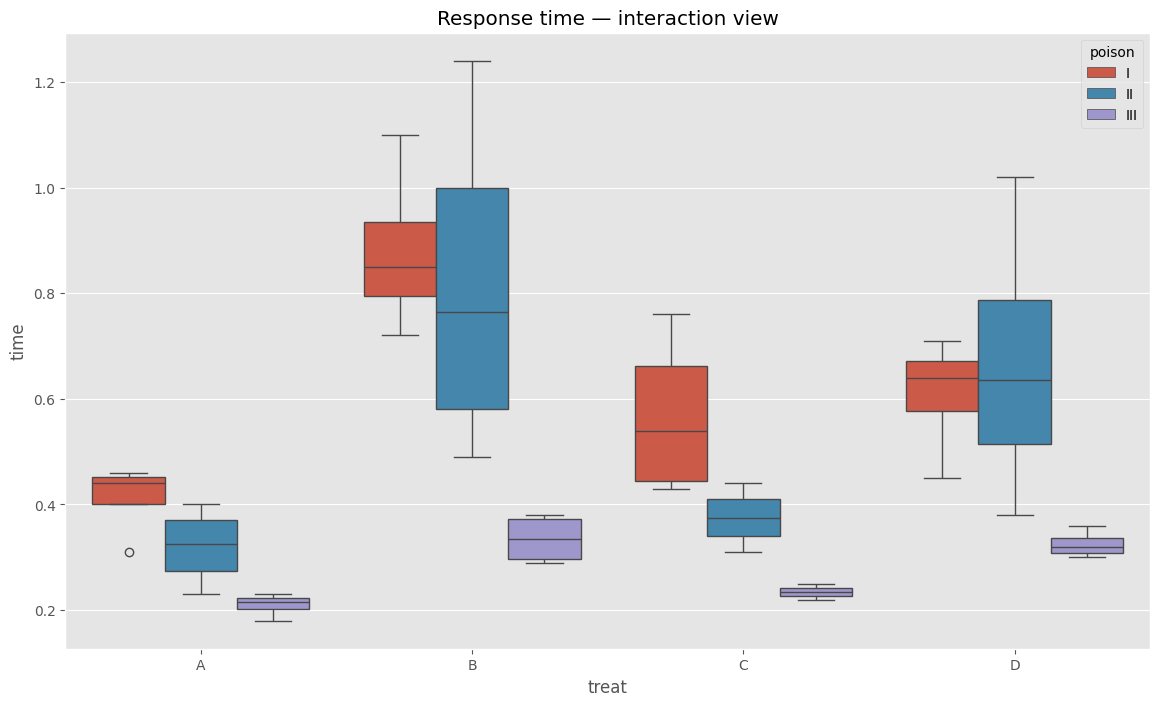

In [ ]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_rats, x='treat', y='time', hue='poison',
            order=['A', 'B', 'C', 'D'], hue_order=['I', 'II', 'III'])
plt.title('Response time — interaction view')
plt.show()

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>iii. דיון בתוצאות</b><br><br>

<b>השפעת רעל:</b>
<ul style="list-style-type: circle;">
<li>קיימת מגמה מונוטונית יורדת — Poison I נותן את זמני התגובה הגבוהים ביותר, ואחריו II ולבסוף III.</li>
<li>ניתן להסיק שרעל III הוא ה"מהיר" או ה"חזק" ביותר מבחינת זמן התגובה שהוא מייצר.</li>
</ul>

<b>השפעת טיפול:</b>
<ul style="list-style-type: circle;">
<li>טיפולים B ו-D מניבים זמני תגובה ארוכים יחסית.</li>
<li>טיפולים A ו-C מניבים זמנים קצרים יותר.</li>
</ul>

<b>הערה חשובה לגבי הנחות המודל:</b>
<ul style="list-style-type: circle;">
<li>מהגרף המשולב רואים ש<b>השונות גדלה עם הממוצע</b> — קבוצות עם זמן תגובה גבוה (למשל Poison I + Treatment B) מציגות פיזור גדול יותר מקבוצות עם זמן נמוך (למשל Poison III + Treatment A).</li>
<li>זוהי <b>Heteroscedasticity</b> — הפרה של הנחת שוויון השונויות שמבחן ANOVA מניח. נחזור לנקודה זו בסעיף ו' שבו נבחן את הנחות המודל גרפית.</li>
</ul>

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ב. המודל התיאורטי של ANOVA דו-כיווני</b><br><br>

נשתמש במודל ANOVA דו-כיווני <b>ללא אינטראקציה</b> (כפי שנדרש בסעיף ג'):
$$y_{ijk} = \mu + \alpha_i + \beta_j + \epsilon_{ijk}$$

כאשר:
<ul style="list-style-type: circle;">
<li>$i = 1, 2, 3$ — רמת הרעל (I, II, III)</li>
<li>$j = 1, 2, 3, 4$ — רמת הטיפול (A, B, C, D)</li>
<li>$k = 1, 2, 3, 4$ — מספר החזרה בתוך התא</li>
</ul>

מרכיבי המודל:
<ul style="list-style-type: circle;">
<li>$y_{ijk}$ — זמן התגובה של עכבר $k$ בתא (רעל $i$, טיפול $j$)</li>
<li>$\mu$ — הממוצע הכללי של זמני התגובה באוכלוסייה</li>
<li>$\alpha_i$ — אפקט עיקרי של רעל $i$ (סטייה מהממוצע הכללי)</li>
<li>$\beta_j$ — אפקט עיקרי של טיפול $j$ (סטייה מהממוצע הכללי)</li>
<li>$\epsilon_{ijk}$ — טעות אקראית</li>
</ul>

<b>אילוצי זיהוי:</b>
$$\sum_{i=1}^{3} \alpha_i = 0, \qquad \sum_{j=1}^{4} \beta_j = 0$$

<b>הנחות המודל:</b>
<ul style="list-style-type: circle;">
<li>נורמליות — $\epsilon_{ijk} \sim N(0, \sigma^2)$</li>
<li>שוויון שונויות — $\text{Var}(\epsilon_{ijk}) = \sigma^2$ קבוע בכל 12 התאים</li>
<li>אי-תלות — $\text{Cov}(\epsilon_{ijk}, \epsilon_{i'j'k'}) = 0$ עבור תצפיות שונות</li>
<li>אדיטיביות (אי-אינטראקציה) — האפקט של רעל קבוע בכל רמות הטיפול ולהפך</li>
</ul>

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ג. אמידת מודל ה-ANOVA הדו-כיווני</b><br><br>

<b>i. השערות המבחן</b><br>
במודל דו-כיווני בודקים שתי השערות נפרדות — אחת לכל גורם.<br><br>

<b>עבור רעל:</b>
$$H_0^{(1)}: \alpha_1 = \alpha_2 = \alpha_3 = 0 \qquad H_1^{(1)}: \text{לפחות אחד מה-}\alpha_i \text{ שונה מאפס}$$

<b>עבור טיפול:</b>
$$H_0^{(2)}: \beta_1 = \beta_2 = \beta_3 = \beta_4 = 0 \qquad H_1^{(2)}: \text{לפחות אחד מה-}\beta_j \text{ שונה מאפס}$$

<b>ii. סטטיסטי המבחן</b><br>
לכל גורם יש סטטיסטי F נפרד:
$$F_{\text{poison}} = \frac{MS_{\text{poison}}}{MS_W} \sim_{H_0} F(a-1,\, N-a-b+1) = F(2, 42)$$
$$F_{\text{treat}} = \frac{MS_{\text{treat}}}{MS_W} \sim_{H_0} F(b-1,\, N-a-b+1) = F(3, 42)$$

כאשר $a = 3$ (רמות רעל), $b = 4$ (רמות טיפול), $N = 48$, ו-$N-a-b+1 = 42$ הן דרגות החופש של השאריות.

</div>

In [ ]:
model_rats = smf.ols('time ~ C(poison) + C(treat)', data=df_rats).fit()
anova_rats = sm.stats.anova_lm(model_rats, typ=2)
anova_rats

,sum_sq,df,F,PR(>F)
C(poison),1.0330,2.0000,20.6433,0.0000
C(treat),0.9212,3.0000,12.2727,0.0000
Residual,1.0509,42.0000,NaN,NaN


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>iii. מדדי טיב התאמה</b><br>
נציג את $R^2$ ואת מדדי המובהקות הכלליים של המודל.

</div>

In [ ]:
pd.DataFrame({
    'Value': [model_rats.rsquared, model_rats.rsquared_adj, model_rats.fvalue, model_rats.f_pvalue]
}, index=['R²', 'Adjusted R²', 'Global F', 'Global p-value'])

,Value
R²,0.6503
Adjusted R²,0.6087
Global F,15.6209
Global p-value,0.0000


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>iv. סיכום הממצאים</b><br><br>

<ul style="list-style-type: circle;">
<li><b>אפקט רעל:</b> $F(2, 42) \approx 20.64$, $p \approx 5.7 \times 10^{-7}$ — מובהק מאוד. דוחים את $H_0^{(1)}$.</li>
<li><b>אפקט טיפול:</b> $F(3, 42) \approx 12.27$, $p \approx 6.7 \times 10^{-6}$ — מובהק מאוד. דוחים את $H_0^{(2)}$.</li>
<li><b>$R^2 \approx 0.65$</b> — המודל מסביר כ-65% מהשונות בזמני התגובה.</li>
</ul>

<b>מסקנה:</b> שני הגורמים (רעל וטיפול) תורמים מובהקית להסברת השונות בזמן התגובה. בסעיף ד' נציג את המודל בצורת רגרסיה, ובסעיף ה' נשווה את הממצאים.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ד. מודל רגרסיה מקביל</b><br><br>

ניתן לכתוב את אותו מודל מסעיף ב' (ANOVA דו-כיווני ללא אינטראקציה) באמצעות משתני דאמי. נגדיר את קבוצת הייחוס: <b>רעל = I</b>, <b>טיפול = A</b>.<br><br>

<b>i. משתני הדאמי</b><br>

עבור רעל (3 רמות → 2 דאמיים):
<ul style="list-style-type: circle;">
<li>$D_2 = 1$ אם רעל = II, אחרת 0</li>
<li>$D_3 = 1$ אם רעל = III, אחרת 0</li>
</ul>

עבור טיפול (4 רמות → 3 דאמיים):
<ul style="list-style-type: circle;">
<li>$T_B = 1$ אם טיפול = B, אחרת 0</li>
<li>$T_C = 1$ אם טיפול = C, אחרת 0</li>
<li>$T_D = 1$ אם טיפול = D, אחרת 0</li>
</ul>

<b>ii. המודל</b><br>
$$y = \beta_0 + \beta_1 D_2 + \beta_2 D_3 + \beta_3 T_B + \beta_4 T_C + \beta_5 T_D + \epsilon$$

<b>iii. פירוש המקדמים</b><br>
<ul style="list-style-type: circle;">
<li>$\beta_0$ — התוחלת בתא הייחוס (Poison=I, Treatment=A)</li>
<li>$\beta_1, \beta_2$ — הפרש בין רעל II, III לעומת I</li>
<li>$\beta_3, \beta_4, \beta_5$ — הפרש בין טיפול B, C, D לעומת A</li>
</ul>

<b>iv. הנחות המודל</b><br>
זהות להנחות מודל ה-ANOVA בסעיף ב':
<ul style="list-style-type: circle;">
<li>נורמליות — $\epsilon \sim N(0, \sigma^2)$</li>
<li>שוויון שונויות — $\text{Var}(\epsilon) = \sigma^2$ קבוע בכל 12 התאים</li>
<li>אי-תלות — תצפיות שונות בלתי תלויות</li>
<li>אדיטיביות — האפקטים של רעל וטיפול מצטברים, ללא אינטראקציה</li>
</ul>

שני המודלים (ANOVA ורגרסיה) הם <b>הצגות שקולות מתמטית של אותה בעיה</b>.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ה. אמידת מודל הרגרסיה והשוואה לסעיף ג'</b><br><br>

נריץ את מודל הרגרסיה שהגדרנו בסעיף ד', עם רעל I וטיפול A כקבוצות הייחוס:

</div>

In [ ]:
model_reg_rats = smf.ols(
    'time ~ C(poison, Treatment(reference="I")) + C(treat, Treatment(reference="A"))',
    data=df_rats
).fit()
model_reg_rats.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   time   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     15.62
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.12e-08
Time:                        08:17:23   Log-Likelihood:                 23.609
No. Observations:                  48   AIC:                            -35.22
Df Residuals:                      42   BIC:                            -23.99
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                      0.4523      0.056      8.088      0.000       0.339       0.565
C(poison, Treatment(reference="I"))[T.II]     -0.0731      0.056     -1.308      0.198      -0.186       0.040
C(poison, Treatment(reference="I"))[T.III]    -0.3413      0.056     -6.102      0.000      -0.454      -0.228
C(treat, Treatment(reference="A"))[T.B]        0.3625      0.065      5.614      0.000       0.232       0.493
C(treat, Treatment(reference="A"))[T.C]        0.0783      0.065      1.213      0.232      -0.052       0.209
C(treat, Treatment(reference="A"))[T.D]        0.2200      0.065      3.407      0.001       0.090       0.350
==============================================================================
Omnibus:                       15.712   Durbin-Watson:                   2.443
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.455
Skew:                           1.154   Prob(JB):                     5.96e-05
Kurtosis:                       5.099   Cond. No.                         5.35
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>i. המשוואה האמודה</b><br>
לאחר ההצבה של המקדמים שאמדנו במודל הכללי מסעיף ד':
$$\hat{y} = 0.452 - 0.073\,D_{II} - 0.341\,D_{III} + 0.363\,T_B + 0.078\,T_C + 0.220\,T_D$$

<b>ii. פירוש המקדמים</b><br>
<ul style="list-style-type: circle;">
<li><b>Intercept</b> $\approx 0.452$ — התוחלת בתא (Poison=I, Treatment=A).</li>
<li><b>C(poison)[T.III]</b> $\approx -0.341$ — רעל III מקטין את זמן התגובה ב-0.341 שניות לעומת רעל I (מובהק).</li>
<li><b>C(poison)[T.II]</b> $\approx -0.073$ — רעל II מקטין במעט (לא מובהק $p \approx 0.20$).</li>
<li><b>C(treat)[T.B]</b> $\approx +0.363$ — טיפול B מאריך את זמן התגובה ב-0.363 לעומת A (מובהק).</li>
<li><b>C(treat)[T.D]</b> $\approx +0.220$ — טיפול D מאריך לעומת A (מובהק).</li>
<li><b>C(treat)[T.C]</b> $\approx +0.078$ — לא מובהק.</li>
</ul>

<b>iii. השוואה לסעיף ג'</b><br>

<ul style="list-style-type: circle;">
<li><b>$R^2 = 0.65$</b> — זהה למדויק לסעיף ג'. שני המודלים מסבירים 65% מהשונות.</li>
<li><b>F הגלובלי</b> של המודל הרגרסיוני ($F(5, 42) \approx 15.62$, $p \approx 1.1 \times 10^{-8}$) בודק את כל 5 המקדמים יחד — שזה <b>לא בדיוק</b> אותו דבר כמו ה-F-ים הנפרדים בסעיף ג', אבל מאשר את אותה תמונה כללית.</li>
<li>ה-F הנפרד של רעל ($F(2, 42) = 20.64$) מסעיף ג' שקול לבדיקת ההשערה $\beta_1 = \beta_2 = 0$ במודל הרגרסיה. ה-F הנפרד של טיפול ($F(3, 42) = 12.27$) שקול לבדיקת $\beta_3 = \beta_4 = \beta_5 = 0$.</li>
</ul>

<b>iv. מסקנה</b><br>
מודל הרגרסיה ומודל ה-ANOVA הם <b>הצגות שקולות מתמטית</b> של אותה בעיה. הם מחזירים אותו $R^2$, אותם אומדני ממוצעים, ואותן מסקנות על מובהקות הגורמים. ההבדל הוא בעיקר בצורת ההצגה: הרגרסיה נותנת מקדמים פרטניים עם פירוש ישיר (הפרשים מקבוצת הייחוס), בעוד שה-ANOVA מסכם כל גורם ל-F יחיד.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ו. בדיקת הנחות המודל גרפית</b><br><br>

לאחר אמידת המודל, נבחן ויזואלית האם הנחותיו מתקיימות. נשתמש בארבעה גרפים סטנדרטיים:

<ul style="list-style-type: circle;">
<li><b>Residuals vs Fitted</b> — בדיקת שוויון שונויות ולינאריות.</li>
<li><b>Normal Q-Q Plot</b> — בדיקת נורמליות של השאריות.</li>
<li><b>Scale-Location</b> — אישוש נוסף לשוויון שונויות.</li>
<li><b>היסטוגרמת השאריות</b> — צורת התפלגות השאריות.</li>
</ul>

</div>

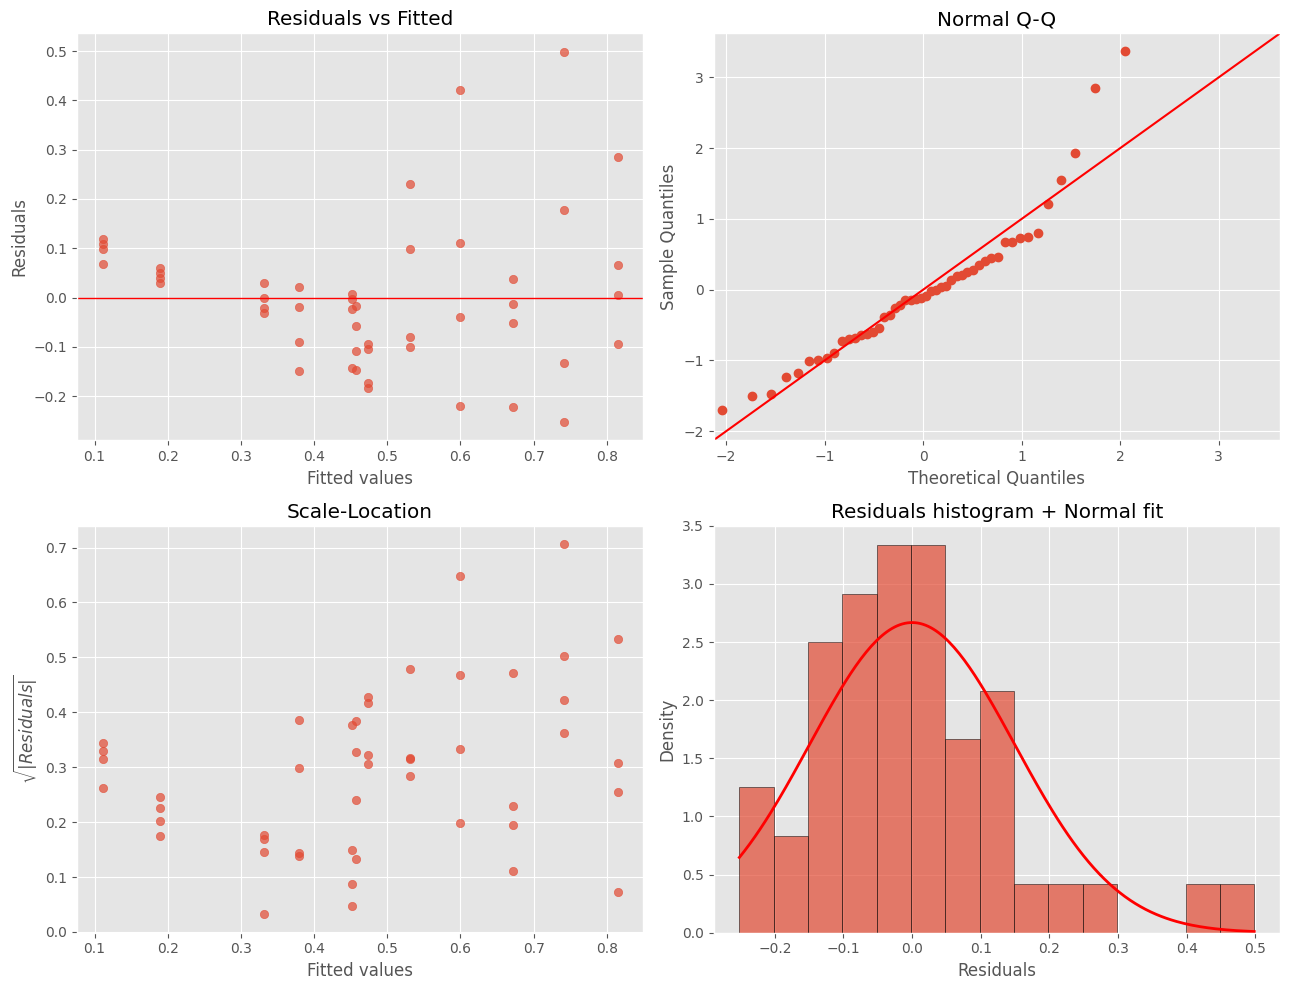

In [ ]:
fitted = model_rats.fittedvalues
resid  = model_rats.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(fitted, resid, alpha=0.7)
axes[0, 0].axhline(0, color='red', lw=1)
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

sm.qqplot(resid, line='45', fit=True, ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q')

axes[1, 0].scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.7)
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel(r'$\sqrt{|Residuals|}$')
axes[1, 0].set_title('Scale-Location')

axes[1, 1].hist(resid, bins=15, density=True, edgecolor='black', alpha=0.7)
xs = np.linspace(resid.min(), resid.max(), 200)
axes[1, 1].plot(xs, stats.norm.pdf(xs, 0, resid.std()), 'r-', lw=2)
axes[1, 1].set_title('Residuals histogram + Normal fit')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Density')

plt.tight_layout()
plt.show()

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>i. מבחן Shapiro-Wilk על השאריות</b><br>
תוספת פורמלית לבדיקת נורמליות:

</div>

In [ ]:
W, p_shap = stats.shapiro(resid)
pd.DataFrame({
    'Value': [W, p_shap, p_shap > 0.05]
}, index=['Shapiro-Wilk W', 'p-value', 'Normality holds?'])

,Value
Shapiro-Wilk W,0.9224
p-value,0.0036
Normality holds?,False


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>ii. דיון בהנחות</b><br><br>

<ul style="list-style-type: circle;">
<li><b>שוויון שונויות (Residuals vs Fitted, Scale-Location):</b> רואים דפוס "מגאפון" ברור — פיזור השאריות גדל עם הערכים החזויים. <b>הנחת ההומוסקדסטיות מופרת בבירור</b>. זו עדות חזקה ל-Heteroscedasticity, בעקביות עם מה שזיהינו ב-Box-Plots בסעיף א'.</li>
<li><b>נורמליות (Q-Q Plot, היסטוגרמה, Shapiro):</b> ה-Q-Q plot מראה סטיות מקו 45° בקצוות, ההיסטוגרמה אסימטרית ימנית, ו-Shapiro דוחה נורמליות ($p < 0.05$). <b>הנחת הנורמליות מופרת.</b></li>
<li><b>אי-תלות:</b> אין דפוס שיטתי של השאריות סביב הקו האפס שמעיד על מתאם — הנחה זו סבירה.</li>
<li><b>אדיטיביות (אי-אינטראקציה):</b> מהגרף של Residuals vs Fitted לא רואים דפוס לא-לינארי ברור, אך הקבוצות עם ערכים חזויים גבוהים מציגות שונות גדולה יותר — מצב שלעיתים מצביע על אינטראקציה.</li>
</ul>

<b>iii. מסקנה</b><br>
שתיים מההנחות החשובות של המודל הקלאסי מופרות: <b>שוויון שונויות</b> ו<b>נורמליות</b>. למרות זאת, בגלל שהמדגם מאוזן ולא קטן (n=48), ANOVA יחסית עמיד להפרות אלו, והתוצאות מסעיף ג' עדיין מספקות אינדיקציה איכותית.<br><br>

לטיפול מעמיק בבעיה — נהוג להפעיל <b>טרנספורמציה הופכית</b> ($1/y$) על זמן התגובה, מה שמייצב את השונות עבור משתנים חיוביים מסוג "זמן עד אירוע". טרנספורמציה זו לא נדרשת בשאלה אך חשוב להכיר אותה כפתרון הקלאסי לבעיה הזו.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ז. פוסט-הוק עם Fisher LSD, Bonferroni, ו-FDR</b><br><br>

מבחן ה-ANOVA בסעיף ג' אישר ששני הגורמים — רעל וטיפול — מובהקים. עתה נבדוק <b>בין אילו רמות בכל גורם</b> קיים הבדל מובהק.<br><br>

נחזור על שלושת התיקונים שראינו בשאלה 3:
<ul style="list-style-type: circle;">
<li><b>Fisher's LSD</b> — t-test רגיל, ללא תיקון. חזק אך לא שולט ב-FWER.</li>
<li><b>Bonferroni</b> — מכפיל ערכי p במספר ההשוואות. שומר על FWER אך שמרני.</li>
<li><b>FDR (BH)</b> — שולט בפרופורציית גילויים שגויים. ביניים.</li>
</ul>

חשוב לציין: התיקונים מתבצעים על <b>כל גורם בנפרד</b> — 3 השוואות לרעלים, 6 השוואות לטיפולים.

</div>

In [ ]:
def posthoc_table(df, group_col, value_col):
    groups = sorted(df[group_col].unique())
    pairs  = list(combinations(groups, 2))

    raw_p = []
    for a, b in pairs:
        d1 = df.loc[df[group_col] == a, value_col]
        d2 = df.loc[df[group_col] == b, value_col]
        _, p = stats.ttest_ind(d1, d2, equal_var=True)
        raw_p.append(p)

    _, bonf, _, _ = multipletests(raw_p, method='bonferroni')
    _, fdr,  _, _ = multipletests(raw_p, method='fdr_bh')

    out = pd.DataFrame({
        'Pair':        [f'{a} vs {b}' for a, b in pairs],
        'LSD':         raw_p,
        'Bonferroni':  bonf,
        'FDR':         fdr,
    })
    out['LSD rej']  = out['LSD']        < 0.05
    out['Bonf rej'] = out['Bonferroni'] < 0.05
    out['FDR rej']  = out['FDR']        < 0.05
    return out.set_index('Pair')

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>i. פוסט-הוק לגורם רעל (3 השוואות זוגיות)</b>

</div>

In [ ]:
posthoc_poison = posthoc_table(df_rats, 'poison', 'time')
posthoc_poison

,LSD,Bonferroni,FDR,LSD rej,Bonf rej,FDR rej
Pair,,,,,,
I vs II,0.4193,1.0000,0.4193,False,False,False
I vs III,0.0000,0.0000,0.0000,True,True,True
II vs III,0.0011,0.0032,0.0016,True,True,True


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>ii. פוסט-הוק לגורם טיפול (6 השוואות זוגיות)</b>

</div>

In [ ]:
posthoc_treat = posthoc_table(df_rats, 'treat', 'time')
posthoc_treat

,LSD,Bonferroni,FDR,LSD rej,Bonf rej,FDR rej
Pair,,,,,,
A vs B,0.0012,0.0070,0.0070,True,True,True
A vs C,0.1798,1.0000,0.2157,False,False,False
A vs D,0.0047,0.0280,0.0140,True,True,True
B vs C,0.0125,0.0748,0.0249,True,False,True
B vs D,0.2174,1.0000,0.2174,False,False,False
C vs D,0.0890,0.5338,0.1334,False,False,False


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>iii. סיכום הממצאים</b><br><br>

<b>רעלים:</b>
<ul style="list-style-type: circle;">
<li>I vs II — לא מובהק באף שיטה ($p \approx 0.42$). הרעלים I ו-II דומים בזמני התגובה שהם מייצרים.</li>
<li>I vs III ו-II vs III — מובהקים בכל השיטות. רעל III שונה מהותית משני הרעלים האחרים.</li>
</ul>

<b>טיפולים:</b>
<ul style="list-style-type: circle;">
<li>A vs B ו-A vs D — מובהקים בכל שלוש השיטות.</li>
<li>B vs C — דוגמה מעניינת להבדל בין השיטות: LSD ו-FDR דוחים ($p \approx 0.013, 0.025$), אך Bonferroni לא ($p \approx 0.075$).</li>
<li>A vs C, B vs D, C vs D — לא מובהקים באף שיטה.</li>
</ul>

<b>iv. השוואה בין השיטות</b><br>
ההבדל בין השיטות בולט בעיקר בזוגות "גבוליים":
<ul style="list-style-type: circle;">
<li><b>Bonferroni</b> מבטל ממצאים גבוליים (כמו B vs C) — שמרני וזהיר.</li>
<li><b>FDR</b> משמר אותם — מאזן בין כוח ושליטה בטעויות.</li>
<li><b>LSD</b> דוחה הכי הרבה — חזק אך עלול לתת ממצאי שווא.</li>
</ul>

<b>מסקנה:</b> רעל III גורם לזמני תגובה שונים מובהקית מ-I ו-II. בקרב הטיפולים, A מובהקית שונה מ-B ומ-D, וייתכן הבדל גם בין B ל-C (תלוי בשיטת התיקון). הבחירה בין השיטות תלויה בהקשר — Bonferroni למסקנות בטוחות, FDR למחקר חקרני.

</div>

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>שאלה 5</b>

להלן נתונים שנאספו ממחקר פורץ דרך על הקשר בין $x$ ל-$y$:</div>

$$\bar{x}=5, \quad \bar{y}=3, \quad n=20, \quad \sum(x_i-\bar{x})^2=160, \quad \sum(y_i-\bar{y})^2=83.2, \quad \sum(x_i-\bar{x})(y_i-\bar{y})=80$$

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>החוקרים הניחו כי המודל הבא מתאר באופן מדויק את הקשר בין $x$ ל-$y$:</div>

$$y_i = \beta_0 + \beta_1 x_i + \epsilon_i$$

<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>א. אמידת משוואת הרגרסיה</b><br><br>

<b>i. הנוסחאות</b><br>
האומדים של פרמטרי הרגרסיה הליניארית הפשוטה:
$$\hat\beta_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} = \frac{S_{xy}}{S_{xx}}$$
$$\hat\beta_0 = \bar{y} - \hat\beta_1 \cdot \bar{x}$$

<b>ii. הצבה</b><br>
$$\hat\beta_1 = \frac{80}{160} = 0.5$$
$$\hat\beta_0 = 3 - 0.5 \cdot 5 = 0.5$$

<b>iii. משוואת הרגרסיה</b><br>
$$\hat{y} = 0.5 + 0.5\, x$$

פירוש: לכל יחידה ש-$x$ עולה, התחזית של $y$ עולה ב-0.5.

</div>

In [ ]:
x_bar, y_bar, n = 5, 3, 20
S_xx, S_yy, S_xy = 160, 83.2, 80

beta1_hat = S_xy / S_xx
beta0_hat = y_bar - beta1_hat * x_bar

pd.DataFrame({
    'Value': [beta0_hat, beta1_hat, f'ŷ = {beta0_hat} + {beta1_hat}·x']
}, index=['β̂₀ (intercept)', 'β̂₁ (slope)', 'Regression equation'])

,Value
β̂₀ (intercept),0.5000
β̂₁ (slope),0.5000
Regression equation,ŷ = 0.5 + 0.5·x


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<hr>

<b>ב. טבלת ANOVA ובחינת מובהקות המודל</b><br><br>

<b>i. השערות המבחן</b><br>
$$H_0: \beta_1 = 0 \qquad H_1: \beta_1 \neq 0$$

תחת $H_0$, אין קשר ליניארי בין $x$ ל-$y$. תחת $H_1$, קיים קשר.<br><br>

<b>ii. סטטיסטי המבחן</b><br>
$$F_s = \frac{MS_{Reg}}{MS_{Res}} \sim_{H_0} F(1,\, n-2) = F(1, 18)$$

<b>iii. חישוב סכומי הריבועים</b><br>
<ul style="list-style-type: circle;">
<li>$SS_T = S_{yy} = 83.2$</li>
<li>$SS_{Reg} = \hat\beta_1 \cdot S_{xy} = 0.5 \cdot 80 = 40$</li>
<li>$SS_{Res} = SS_T - SS_{Reg} = 83.2 - 40 = 43.2$</li>
</ul>

<b>iv. ממוצעים ריבועיים</b><br>
<ul style="list-style-type: circle;">
<li>$MS_{Reg} = SS_{Reg} / df_{Reg} = 40 / 1 = 40$</li>
<li>$MS_{Res} = SS_{Res} / df_{Res} = 43.2 / 18 = 2.4$</li>
</ul>

<b>v. סטטיסטי F</b><br>
$$F_s = \frac{40}{2.4} \approx 16.67$$

</div>

In [ ]:
SS_reg = beta1_hat * S_xy
SS_res = S_yy - SS_reg
SS_tot = S_yy

df_reg, df_res = 1, n - 2
MS_reg = SS_reg / df_reg
MS_res = SS_res / df_res
F_s    = MS_reg / MS_res
p_val  = 1 - stats.f.cdf(F_s, df_reg, df_res)
F_c    = stats.f.ppf(0.95, df_reg, df_res)
R2     = SS_reg / SS_tot

anova_q5 = pd.DataFrame({
    'df':      [df_reg, df_res, df_reg + df_res],
    'SS':      [SS_reg, SS_res, SS_tot],
    'MS':      [MS_reg, MS_res, np.nan],
    'F':       [F_s, np.nan, np.nan],
    'p-value': [p_val, np.nan, np.nan]
}, index=['Regression', 'Residual', 'Total'])
anova_q5

,df,SS,MS,F,p-value
Regression,1,40.0000,40.0000,16.6667,0.0007
Residual,18,43.2000,2.4000,NaN,NaN
Total,19,83.2000,NaN,NaN,NaN


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>vi. ערך קריטי, p-value ו-$R^2$</b>

</div>

In [ ]:
pd.DataFrame({
    'Value': [F_s, F_c, p_val, R2, F_s > F_c]
}, index=['F_s', 'F_c (α=0.05)', 'p-value', 'R²', 'Reject H₀?'])

,Value
F_s,16.6667
F_c (α=0.05),4.4139
p-value,0.0007
R²,0.4808
Reject H₀?,True


<div dir='rtl' style='text-align:right; font-family: "Calibri", sans-serif; font-size: 12pt; line-height: 1.5;'>

<b>vii. מסקנה</b><br>
$$F_s \approx 16.67 > F_c \approx 4.41 \qquad p\text{-value} \approx 0.0007 < \alpha = 0.05$$

מאחר שהסטטיסטי עבר את הערך הקריטי (וה-p-value קטן מ-$\alpha$), <b>דוחים את $H_0$</b> — קיים קשר ליניארי מובהק בין $x$ ל-$y$.<br><br>

$R^2 \approx 0.481$ — המודל מסביר כ-48% מהשונות ב-$y$.

</div>